# Bitcoin Price Forecasting Using CNN-LSTM

This notebook is an explained copy of `FDA_project_original (1).ipynb`.

The original code cells are preserved, and explanatory markdown headers have been added before each major section. The project workflow is:

1. Collect Bitcoin market, sentiment, ETF, and on-chain data.
2. Clean and transform the datasets into modeling-ready CSV files.
3. Merge datasets by date.
4. Create lagged and scaled time-series features.
5. Train and compare CNN-LSTM models using RMSE and MAE.


## Section 1: Fetch Fear & Greed Index Data

This cell calls the Alternative.me Fear & Greed Index API and prints historical sentiment values from the selected start date. The Fear & Greed Index is used as a market sentiment feature, where low values indicate fear and high values indicate greed.

Main idea: collect sentiment data that may help explain Bitcoin price movements.


In [ ]:
import requests
import json
from datetime import datetime

# Define the API endpoint
url = "https://api.alternative.me/fng/?limit=0"  # 'limit=0' fetches all historical data

def fetch_fear_and_greed_index(start_date):
    try:
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()['data']
            start_timestamp = int(datetime.strptime(start_date, "%Y-%m-%d").timestamp())

            # Filter data from the start date to today
            filtered_data = [
                item for item in data if int(item['timestamp']) >= start_timestamp
            ]

            # Display the results
            for entry in filtered_data:
                index_value = entry['value']
                classification = entry['value_classification']
                timestamp = datetime.fromtimestamp(int(entry['timestamp'])).strftime('%Y-%m-%d')
                print(f"Date: {timestamp} | Fear & Greed Index: {index_value} - {classification}")
        else:
            print(f"Failed to fetch data. Status Code: {response.status_code}")
    except Exception as e:
        print(f"An error occurred: {e}")

# Example usage: Fetch from a specific start date to today
fetch_fear_and_greed_index("2018-01-01")


Date: 2024-10-12 | Fear & Greed Index: 49 - Neutral
Date: 2024-10-11 | Fear & Greed Index: 32 - Fear
Date: 2024-10-10 | Fear & Greed Index: 39 - Fear
Date: 2024-10-09 | Fear & Greed Index: 49 - Neutral
Date: 2024-10-08 | Fear & Greed Index: 49 - Neutral
Date: 2024-10-07 | Fear & Greed Index: 50 - Neutral
Date: 2024-10-06 | Fear & Greed Index: 50 - Neutral
Date: 2024-10-05 | Fear & Greed Index: 49 - Neutral
Date: 2024-10-04 | Fear & Greed Index: 41 - Fear
Date: 2024-10-03 | Fear & Greed Index: 37 - Fear
Date: 2024-10-02 | Fear & Greed Index: 42 - Fear
Date: 2024-10-01 | Fear & Greed Index: 50 - Neutral
Date: 2024-09-30 | Fear & Greed Index: 61 - Greed
Date: 2024-09-29 | Fear & Greed Index: 63 - Greed
Date: 2024-09-28 | Fear & Greed Index: 64 - Greed
Date: 2024-09-27 | Fear & Greed Index: 61 - Greed
Date: 2024-09-26 | Fear & Greed Index: 50 - Neutral
Date: 2024-09-25 | Fear & Greed Index: 59 - Greed
Date: 2024-09-24 | Fear & Greed Index: 54 - Neutral
Date: 2024-09-23 | Fear & Greed Index

## Section 2: Export Fear & Greed Index to CSV

This cell repeats the API request, filters records from 2018 onward, converts the result into a pandas DataFrame, and saves it as `fear_and_greed_index.csv`.

Main idea: store API data locally so the model can reuse it without calling the API every time.


In [ ]:
import requests
import json
from datetime import datetime
import pandas as pd

# API endpoint
url = "https://api.alternative.me/fng/?limit=0"

def fetch_and_export_fear_and_greed_index(start_date, output_path):
    try:
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()['data']
            start_timestamp = int(datetime.strptime(start_date, "%Y-%m-%d").timestamp())

            # Filter the data
            filtered_data = [
                {
                    "Date": datetime.fromtimestamp(int(item['timestamp'])).strftime('%Y-%m-%d'),
                    "Value": item['value'],
                    "Classification": item['value_classification']
                }
                for item in data if int(item['timestamp']) >= start_timestamp
            ]

            # Convert to DataFrame and export to CSV
            df = pd.DataFrame(filtered_data)
            df.to_csv(output_path, index=False)
            print(f"Data successfully saved to {output_path}")
        else:
            print(f"Failed to fetch data. Status Code: {response.status_code}")
    except Exception as e:
        print(f"An error occurred: {e}")

# Specify output path
output_csv_path = "fear_and_greed_index.csv"

# Fetch and export data
fetch_and_export_fear_and_greed_index("2018-01-01", output_csv_path)


Data successfully saved to fear_and_greed_index.csv


## Section 3: Download Active Bitcoin Address Data

This cell downloads active Bitcoin address information from the Blockchair API and saves the response to `active_bitcoin_addresses.csv`.

Main idea: active address data is an on-chain signal that can represent network activity and user participation.


In [ ]:
import requests

# Define the API endpoint for active addresses
url = "https://api.blockchair.com/bitcoin/addresses?active=true&since=2018-01-01&format=csv"

def download_csv(url, save_path):
    try:
        # Send GET request to download the CSV
        response = requests.get(url)

        # Check if the request was successful
        if response.status_code == 200:
            # Save the content as a CSV file
            with open(save_path, 'wb') as f:
                f.write(response.content)
            print(f"CSV successfully downloaded and saved to {save_path}")
        else:
            print(f"Failed to fetch data. Status code: {response.status_code}")
    except Exception as e:
        print(f"An error occurred: {e}")

# Define the path to save the CSV
csv_path = "active_bitcoin_addresses.csv"

# Call the function to download and save the CSV
download_csv(url, csv_path)


CSV successfully downloaded and saved to active_bitcoin_addresses.csv


## Section 4: Convert Daily Active Address JSON to CSV

This cell shows how a JSON file containing daily active-address information can be converted into a tabular CSV format.

Main idea: machine-learning models work more easily with table-shaped data, so raw JSON data is transformed into rows and columns.


In [ ]:
import json
import pandas as pd

# Load the JSON data from the uploaded file
file_path = "/mnt/data/daily_active_addresses.json"

with open(file_path, "r") as f:
    data = json.load(f)

# Prepare a list to store the extracted information
address_data = []

# Extract date and relevant data from JSON
for date, value in data.items():
    # Assuming the context might contain the relevant state or active addresses (example scenario)
    active_addresses = value.get("context", {}).get("state", None)
    address_data.append({"Date": date, "Active_Addresses": active_addresses})

# Convert to DataFrame
df = pd.DataFrame(address_data)

# Save as CSV
csv_path = "/mnt/data/daily_active_addresses.csv"
df.to_csv(csv_path, index=False)

csv_path


## Section 5: On-Chain Metrics from the Boruta Dataset

The next cells prepare on-chain indicators selected for the model. These indicators help describe Bitcoin network behavior and valuation conditions.

The first metric in this section is SOPR.


# data from Boruta dataset
1. SOPR

### 5.1 SOPR Filtering

This cell loads `SOPR.json`, converts its date column, filters the dataset to keep only observations from 2018 onward, and saves the result as `filtered_sopr_2018_onwards.csv`.

SOPR can help identify whether coins moved on-chain are generally being sold at profit or loss.


In [ ]:
import pandas as pd

# Load the JSON file to analyze
file_path = 'SOPR.json'
data = pd.read_json(file_path)

# Convert date strings to datetime for filtering
data['d'] = pd.to_datetime(data['d'])

# Filter data to only include dates from 2018 onwards
filtered_data = data[data['d'] >= '2018-01-01']

# Save the filtered data to a CSV file
csv_file_path = 'filtered_sopr_2018_onwards.csv'
filtered_data.to_csv(csv_file_path, index=False)





2. Cdd Coin days destroyed

### 5.2 CDD 90DMA Collection

This cell fetches Coin Days Destroyed 90-day moving average data from `bitcoin-data.com` and saves it as `cdd_90dma_data.csv`.

CDD 90DMA is useful because it can reflect movement from older coins, which may signal changes in long-term holder behavior.


In [ ]:
import requests
import pandas as pd

# Define the URL and headers
url = 'https://bitcoin-data.com/v1/cdd-90dma?startday=2018-01-01'
headers = {
    'accept': 'application/hal+json',
}

# Send the GET request
response = requests.get(url, headers=headers)

# Check if the request was successful
if response.status_code == 200:
    # Parse the JSON data
    data = response.json()

    # Assuming the data is a list of dictionaries, convert it to a DataFrame
    df = pd.DataFrame(data)

    # Save to CSV
    df.to_csv('cdd_90dma_data.csv', index=False)
    print("Data saved to 'cdd_90dma_data.csv'")
else:
    print(f"Failed to retrieve data. Status code: {response.status_code}")


Data saved to 'cdd_90dma_data.csv'


3. MVRV

### 5.3 MVRV Filtering

This cell loads `MVRV.json`, converts the date field, filters data from 2018 onward, and saves it as `filtered_MVRV_2018_onwards.csv`.

MVRV compares market value with realized value and is often used to study whether Bitcoin may be overvalued or undervalued.


In [ ]:
import pandas as pd

# Load the JSON file to analyze
file_path = 'MVRV.json'
data = pd.read_json(file_path)

# Convert date strings to datetime for filtering
data['d'] = pd.to_datetime(data['d'])

# Filter data to only include dates from 2018 onwards
filtered_data = data[data['d'] >= '2018-01-01']

# Save the filtered data to a CSV file
csv_file_path = 'filtered_MVRV_2018_onwards.csv'
filtered_data.to_csv(csv_file_path, index=False)





4. MVRV z-Score

### 5.4 MVRV Z-Score Filtering

This cell prepares `MVRV-Zscore.json` in the same way as the previous on-chain files. It saves the filtered output as `filtered_MVRV-Zscore_2018_onwards.csv`.

MVRV Z-score standardizes the MVRV signal and can help detect extreme valuation conditions.


In [ ]:
import pandas as pd

# Load the JSON file to analyze
file_path = 'MVRV-Zscore.json'
data = pd.read_json(file_path)

# Convert date strings to datetime for filtering
data['d'] = pd.to_datetime(data['d'])

# Filter data to only include dates from 2018 onwards
filtered_data = data[data['d'] >= '2018-01-01']

# Save the filtered data to a CSV file
csv_file_path = 'filtered_MVRV-Zscore_2018_onwards.csv'
filtered_data.to_csv(csv_file_path, index=False)



5.

### 5.5 Placeholder Cell

This code cell is empty in the original notebook. It is kept here so this explained notebook remains a faithful copy of the original structure.


# fill empty active address number


## Section 6: Fill Missing Daily Unique-Address Values

This cell creates a complete daily date range, merges it with the unique-address dataset, and forward-fills missing values.

Main idea: the model expects consistent daily data. Forward filling keeps the time series continuous when values are missing.


In [ ]:
import pandas as pd

# Load the CSV file containing daily active addresses
file_path = "n_unique_addresses_daily.csv"
addresses_data = pd.read_csv(file_path)

# Ensure the 'Date' column is in datetime format
addresses_data['Date'] = pd.to_datetime(addresses_data['Date'])

# Generate a complete date range from the minimum to the maximum date in the dataset
full_date_range = pd.DataFrame({'Date': pd.date_range(start=addresses_data['Date'].min(),
                                                      end=addresses_data['Date'].max())})

# Merge the complete date range with the original data
merged_data = pd.merge(full_date_range, addresses_data, on='Date', how='left')

# Replace missing values (NaN) with 0 initially
merged_data['Unique_Addresses'] = merged_data['Unique_Addresses'].fillna(0)

# Replace 0 values with the previous valid value if available, else keep it as 0
filled_data_corrected = merged_data.replace(0, pd.NA).ffill().fillna(0)

# Save the corrected data to a new CSV file
final_csv_path = "filled_n_unique_addresses_daily_corrected.csv"
filled_data_corrected.to_csv(final_csv_path, index=False)

final_csv_path


<ipython-input-11-3f28e9993ff0>:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filled_data_corrected = merged_data.replace(0, pd.NA).ffill().fillna(0)


'filled_n_unique_addresses_daily_corrected.csv'

### 6.1 Placeholder Cell

This code cell is empty in the original notebook and is preserved for completeness.


# change fear and greeed to int

## Section 7: Encode Fear & Greed Classification Labels

This cell converts text labels such as `Extreme Fear`, `Fear`, `Neutral`, `Greed`, and `Extreme Greed` into numbers from 0 to 4.

Main idea: neural networks require numeric inputs, so sentiment categories must be encoded before modeling.


In [ ]:
import pandas as pd

# Load the Fear & Greed Index CSV
file_path = "fear_and_greed_index.csv"
fear_greed_data = pd.read_csv(file_path)

# Step 3: Define a mapping dictionary
classification_mapping = {
    "Extreme Fear": 0,
    "Fear": 1,
    "Neutral": 2,
    "Greed": 3,
    "Extreme Greed": 4
}

# Step 4: Map the 'Classification' column using the dictionary
fear_greed_data['Classification'] = fear_greed_data['Classification'].map(classification_mapping)

# Check if all classifications were correctly mapped
print(fear_greed_data.head())

# Save the updated dataset to a new CSV file
encoded_fear_greed_path = "encoded_fear_and_greed_index.csv"
fear_greed_data.to_csv(encoded_fear_greed_path, index=False)

print(f"Encoded data saved to: {encoded_fear_greed_path}")


       Date  Value  Classification
0  2/1/2018     30               1
1  2/2/2018     15               0
2  2/3/2018     40               1
3  2/4/2018     24               0
4  2/5/2018     11               0
Encoded data saved to: encoded_fear_and_greed_index.csv


# trading volume for json to csv


## Section 8: Convert Trade Volume JSON to CSV

This cell reads `trade-volume.json`, extracts timestamps and volume values, converts timestamps into dates, and saves the result as `trade_volume.csv`.

Main idea: convert raw time-series JSON into a modeling-friendly CSV file.


In [ ]:
import pandas as pd
import json
from datetime import datetime

# Load the JSON data from the uploaded file
file_path = "trade-volume.json"
with open(file_path, "r") as f:
    trade_data = json.load(f)

# Extract the 'x' (timestamp) and 'y' (trade volume) values
data = [
    {"Date": datetime.utcfromtimestamp(item["x"] / 1000).strftime('%Y-%m-%d'), "Trade_Volume": item["y"]}
    for item in trade_data["trade-volume"]
]

# Convert to DataFrame
df = pd.DataFrame(data)

# Save as CSV
output_path = "trade_volume.csv"
df.to_csv(output_path, index=False)

output_path


'trade_volume.csv'

## Section 9: Download Bitcoin Volume Data with yfinance

This cell downloads Bitcoin volume data from Yahoo Finance and saves the `Volume` column as `btc_volume_since_2018.csv`.

Main idea: trading volume can provide information about market activity and liquidity.


In [ ]:
import yfinance as yf
import pandas as pd

# Fetch BTC data from Yahoo Finance since 2018
btc_data = yf.download('BTC-USD', start='2018-01-01', end='2024-01-01', interval='1d')

# Extract the 'Volume' column and reset the index
btc_volume = btc_data[['Volume']].reset_index()

# Ensure 'Date' is in datetime format
btc_volume['Date'] = pd.to_datetime(btc_volume['Date'])

# Forward fill any missing values
btc_volume = btc_volume.ffill()

# Export the data as a CSV file
btc_volume.to_csv('btc_volume_since_2018.csv', index=False)

print("BTC Volume data has been saved as 'btc_volume_since_2018.csv'.")


[*********************100%***********************]  1 of 1 completed

BTC Volume data has been saved as 'btc_volume_since_2018.csv'.


# BTC price data



## Section 10: Install yfinance

This cell installs the `yfinance` library in Google Colab. It is needed for downloading Bitcoin price and volume data from Yahoo Finance.

If you already have `yfinance` installed, this cell may not need to be run again.


In [ ]:
pip install yfinance


## Section 11: Download Bitcoin Price Data

This cell downloads daily Bitcoin OHLCV data from Yahoo Finance and saves it as `btc_price.csv`.

The model later uses the `Close` price as the prediction target.


In [ ]:
import yfinance as yf
import pandas as pd

# Fetch Bitcoin price data from Yahoo Finance
btc_data = yf.download(tickers='BTC-USD', start='2018-01-01', end='2024-10-12', interval='1d')

# Display the first few rows
print(btc_data.head())

# Save the data to a CSV file
btc_data.to_csv('btc_price.csv')
print("Bitcoin price data saved to 'btc_price.csv'")


[*********************100%***********************]  1 of 1 completed

                    Open          High           Low         Close  \
Date                                                                 
2018-01-01  14112.200195  14112.200195  13154.700195  13657.200195   
2018-01-02  13625.000000  15444.599609  13163.599609  14982.099609   
2018-01-03  14978.200195  15572.799805  14844.500000  15201.000000   
2018-01-04  15270.700195  15739.700195  14522.200195  15599.200195   
2018-01-05  15477.200195  17705.199219  15202.799805  17429.500000   

               Adj Close       Volume  
Date                                   
2018-01-01  13657.200195  10291200000  
2018-01-02  14982.099609  16846600192  
2018-01-03  15201.000000  16871900160  
2018-01-04  15599.200195  21783199744  
2018-01-05  17429.500000  23840899072  
Bitcoin price data saved to 'btc_price.csv'



# MODEL

## Section 12: Install Modeling Libraries

This cell installs the main Python packages used for modeling:

- pandas and NumPy for data handling
- TensorFlow/Keras for the CNN-LSTM neural network
- scikit-learn for scaling, splitting, and metrics
- matplotlib for plots


In [ ]:
pip install pandas numpy tensorflow scikit-learn matplotlib


## Section 13: Mount Google Drive

This cell mounts Google Drive in Colab so the notebook can read project files from `/content/drive/MyDrive/FDA/`.

If running locally, replace these Colab paths with local file paths.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 13.1 Placeholder Cell

This code cell is empty in the original notebook and is preserved for completeness.


## Section 14: CNN-LSTM Model Training and Evaluation

This is the main modeling section. It loads the prepared datasets, aligns them by date, creates features, scales the data, builds sliding-window sequences, trains three CNN-LSTM models, and compares them using RMSE and MAE.

Model comparison:

- Model 1 uses on-chain metrics only.
- Model 2 adds the Fear & Greed Index.
- Model 3 adds ETF inflow data.

The plots at the end compare predicted prices, training loss, and error metrics.

Note: in the original notebook, the ETF model references `data_with_fear_greed_etf`, but the variable created above it is named `data_with_etf`. If you rerun this notebook and get a NameError in this section, rename the variable consistently.


<ipython-input-17-4128c1d9f1c2>:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  btc_etf_volume['Date'] = pd.to_datetime(btc_etf_volume['Date'])
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 886ms/step
Model 1 (6 Variables) | RMSE: 4843.7662 | MAE: 3187.3234
Model 2 (6 Variables + Fear & Greed) | RMSE: 9774.2274 | MAE: 6408.9271
Model 3 (6 Variables + ETF Inflow) | RMSE: 5701.7242 | MAE: 4582.2892


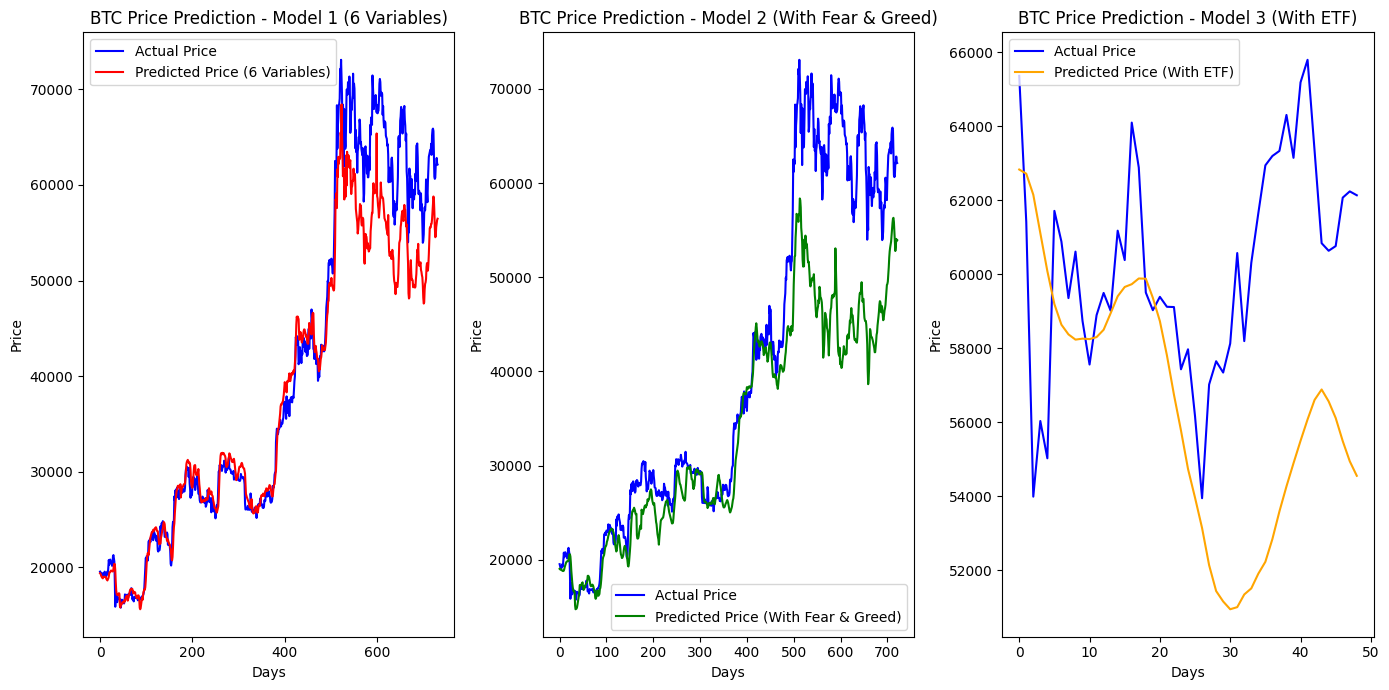

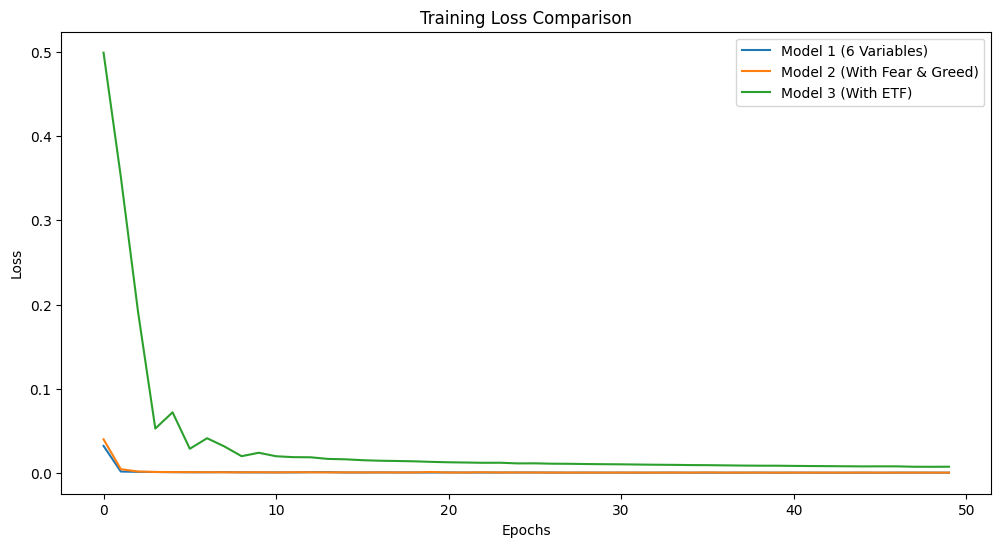

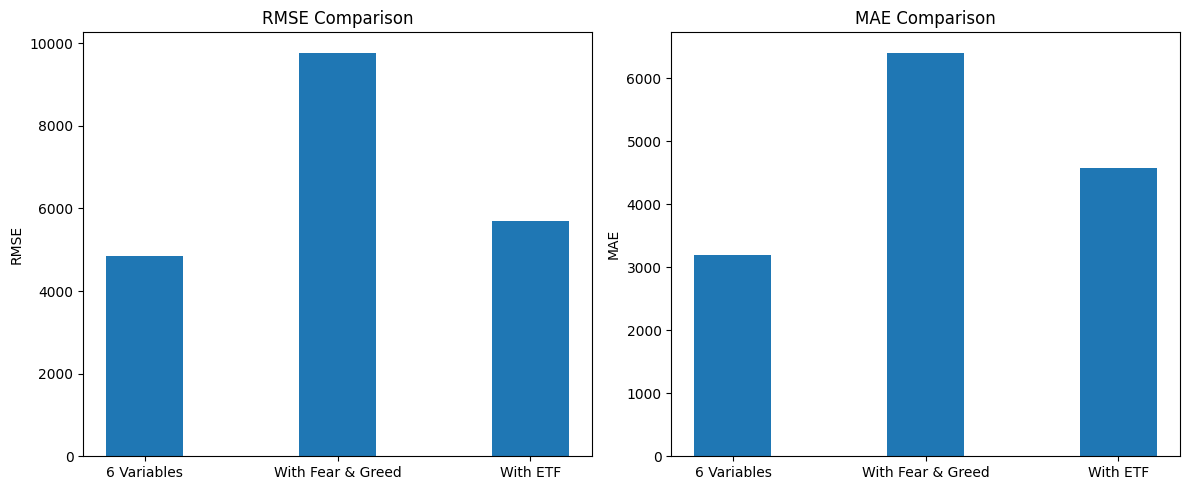

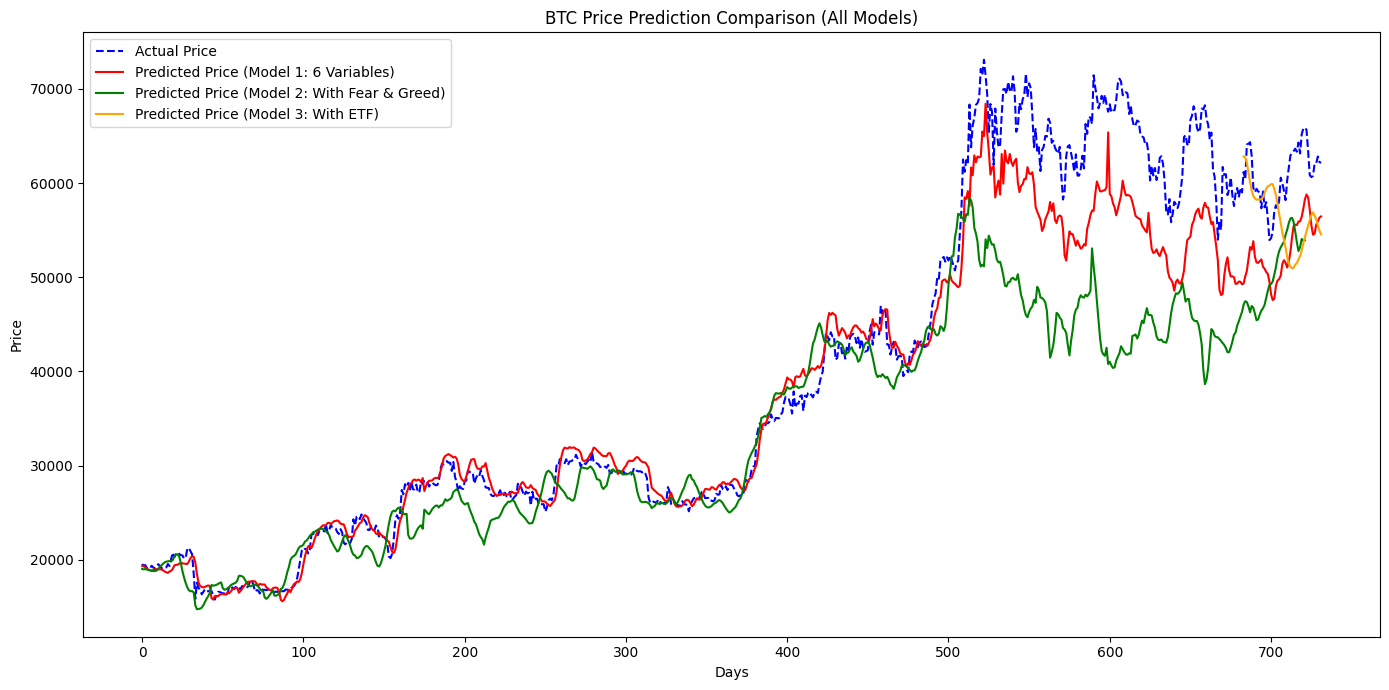

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, TimeDistributed, Reshape
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Step 1: Load the datasets
btc_price = pd.read_csv('/content/drive/MyDrive/FDA/btc_price.csv')  # Your BTC price data file
fear_greed = pd.read_csv('/content/drive/MyDrive/FDA/encoded_fear_and_greed_index.csv')  # Fear & Greed index data
active_addresses = pd.read_csv('/content/drive/MyDrive/FDA/filled_n_unique_addresses_daily_corrected.csv')  # Active addresses data
btc_etf_volume = pd.read_csv('/content/drive/MyDrive/FDA/ETF-inflow.csv')  # BTC ETF volume data
mvrv_zscore = pd.read_csv('/content/drive/MyDrive/FDA/filtered_MVRV-Zscore_2018_onwards.csv')
mvrv = pd.read_csv('/content/drive/MyDrive/FDA/filtered_MVRV_2018_onwards.csv')
cdd_90dma = pd.read_csv('/content/drive/MyDrive/FDA/cdd_90dma_data.csv')
sopr = pd.read_csv('/content/drive/MyDrive/FDA/filtered_sopr_2018_onwards.csv')

# Ensure 'Date' is in datetime format for all datasets
btc_price['Date'] = pd.to_datetime(btc_price['Date'])
fear_greed['Date'] = pd.to_datetime(fear_greed['Date'])
active_addresses['Date'] = pd.to_datetime(active_addresses['Date'])
mvrv_zscore['Date'] = pd.to_datetime(mvrv_zscore['d'])
mvrv['Date'] = pd.to_datetime(mvrv['d'])
cdd_90dma['Date'] = pd.to_datetime(cdd_90dma['d'])
sopr['Date'] = pd.to_datetime(sopr['d'])
btc_etf_volume['Date'] = pd.to_datetime(btc_etf_volume['Date'])

# Rename and drop unnecessary columns in new datasets
mvrv_zscore = mvrv_zscore.rename(columns={"mvrvZscore": "MVRV_Zscore"}).drop(columns=['d', 'unixTs'])
mvrv = mvrv.rename(columns={"mvrv": "MVRV"}).drop(columns=['d', 'unixTs'])
cdd_90dma = cdd_90dma.rename(columns={"cdd90dma": "CDD_90DMA"}).drop(columns=['d', 'unixTs'])
sopr = sopr.rename(columns={"sopr": "SOPR"}).drop(columns=['d', 'unixTs'])

# Merge datasets on 'Date'
data = pd.merge(btc_price[['Date', 'Close']], active_addresses[['Date', 'Unique_Addresses']], on='Date', how='inner')

# Merge additional variables for all models
data = pd.merge(data, mvrv_zscore[['Date', 'MVRV_Zscore']], on='Date', how='inner')
data = pd.merge(data, mvrv[['Date', 'MVRV']], on='Date', how='inner')
data = pd.merge(data, cdd_90dma[['Date', 'CDD_90DMA']], on='Date', how='inner')
data = pd.merge(data, sopr[['Date', 'SOPR']], on='Date', how='inner')

# Add Price Lag (Close Price Lagged by 1 Day)
data['Price_Lag_1'] = data['Close'].shift(1)
data = data.dropna()

# Step 2: Prepare Features for 3 Models
# Model 1: Original 6 Variables (On-chain Metrics)
features_model_1 = data[['Unique_Addresses', 'MVRV_Zscore', 'MVRV', 'CDD_90DMA', 'SOPR', 'Price_Lag_1']]
target_model_1 = data['Close']

# Model 2: 6 Variables + Fear & Greed Index
data_with_fear_greed = pd.merge(data, fear_greed[['Date', 'Value']],on='Date', how='inner')
features_model_2 = data_with_fear_greed[['Value', 'Unique_Addresses', 'MVRV_Zscore', 'MVRV', 'CDD_90DMA', 'SOPR', 'Price_Lag_1']]
target_model_2 = data_with_fear_greed['Close']

# Model 3: 6 Variables + Fear & Greed Index + ETF Inflow
data_with_etf = pd.merge(data, btc_etf_volume[['Date', 'Total']], on='Date', how='inner')
features_model_3 = data_with_fear_greed_etf[[ 'Unique_Addresses', 'MVRV_Zscore', 'MVRV', 'CDD_90DMA', 'SOPR', 'Price_Lag_1', 'Total']]
target_model_3 = data_with_fear_greed_etf['Close']

# Step 3: Scale Features and Target for All Models
scaler_features_1 = MinMaxScaler()
scaler_target_1 = MinMaxScaler()
scaled_features_1 = scaler_features_1.fit_transform(features_model_1)
scaled_target_1 = scaler_target_1.fit_transform(target_model_1.values.reshape(-1, 1))

scaler_features_2 = MinMaxScaler()
scaler_target_2 = MinMaxScaler()
scaled_features_2 = scaler_features_2.fit_transform(features_model_2)
scaled_target_2 = scaler_target_2.fit_transform(target_model_2.values.reshape(-1, 1))

scaler_features_3 = MinMaxScaler()
scaler_target_3 = MinMaxScaler()
scaled_features_3 = scaler_features_3.fit_transform(features_model_3)
scaled_target_3 = scaler_target_3.fit_transform(target_model_3.values.reshape(-1, 1))

# Step 4: Train-Test Split (70:30) for All Models
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(scaled_features_1, scaled_target_1, test_size=0.3, shuffle=False)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(scaled_features_2, scaled_target_2, test_size=0.3, shuffle=False)
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(scaled_features_3, scaled_target_3, test_size=0.3, shuffle=False)

# Reshape Data for CNN-LSTM Input
def create_sequences(X, y, window_size=10):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i + window_size])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)

window_size = 10
X_train_seq_1, y_train_seq_1 = create_sequences(X_train_1, y_train_1, window_size)
X_test_seq_1, y_test_seq_1 = create_sequences(X_test_1, y_test_1, window_size)

X_train_seq_2, y_train_seq_2 = create_sequences(X_train_2, y_train_2, window_size)
X_test_seq_2, y_test_seq_2 = create_sequences(X_test_2, y_test_2, window_size)

X_train_seq_3, y_train_seq_3 = create_sequences(X_train_3, y_train_3, window_size)
X_test_seq_3, y_test_seq_3 = create_sequences(X_test_3, y_test_3, window_size)

# Step 5: Build and Compile Model
def build_model(input_shape):
    model = Sequential()
    model.add(TimeDistributed(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'), input_shape=input_shape))
    model.add(TimeDistributed(MaxPooling1D(pool_size=2)))
    model.add(TimeDistributed(Flatten()))
    model.add(Reshape((window_size, -1)))
    model.add(LSTM(50, activation='relu', return_sequences=True))
    model.add(LSTM(50, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and Train Models for All Cases
model_1 = build_model((window_size, 6, 1))  # Model with 6 Variables
model_2 = build_model((window_size, 7, 1))  # Model with Fear & Greed Index
model_3 = build_model((window_size, 7, 1))  # Model with ETF inflow

# Continue training for Model 1, 2, and 3
history_1 = model_1.fit(X_train_seq_1, y_train_seq_1, epochs=50, batch_size=32, validation_data=(X_test_seq_1, y_test_seq_1), verbose=0)
history_2 = model_2.fit(X_train_seq_2, y_train_seq_2, epochs=50, batch_size=32, validation_data=(X_test_seq_2, y_test_seq_2), verbose=0)
history_3 = model_3.fit(X_train_seq_3, y_train_seq_3, epochs=50, batch_size=32, validation_data=(X_test_seq_3, y_test_seq_3), verbose=0)

# Step 6: Evaluate Models
y_pred_1 = model_1.predict(X_test_seq_1)
y_pred_2 = model_2.predict(X_test_seq_2)
y_pred_3 = model_3.predict(X_test_seq_3)

# Inverse transform predictions and actuals for each model
y_pred_inv_1 = scaler_target_1.inverse_transform(y_pred_1)
y_pred_inv_2 = scaler_target_2.inverse_transform(y_pred_2)
y_pred_inv_3 = scaler_target_3.inverse_transform(y_pred_3)

y_test_inv_1 = scaler_target_1.inverse_transform(y_test_seq_1)
y_test_inv_2 = scaler_target_2.inverse_transform(y_test_seq_2)
y_test_inv_3 = scaler_target_3.inverse_transform(y_test_seq_3)

# Calculate RMSE and MAE for each model
rmse_1 = np.sqrt(mean_squared_error(y_test_inv_1, y_pred_inv_1))
rmse_2 = np.sqrt(mean_squared_error(y_test_inv_2, y_pred_inv_2))
rmse_3 = np.sqrt(mean_squared_error(y_test_inv_3, y_pred_inv_3))

mae_1 = mean_absolute_error(y_test_inv_1, y_pred_inv_1)
mae_2 = mean_absolute_error(y_test_inv_2, y_pred_inv_2)
mae_3 = mean_absolute_error(y_test_inv_3, y_pred_inv_3)

# Print Evaluation Metrics
print(f'Model 1 (6 Variables) | RMSE: {rmse_1:.4f} | MAE: {mae_1:.4f}')
print(f'Model 2 (6 Variables + Fear & Greed) | RMSE: {rmse_2:.4f} | MAE: {mae_2:.4f}')
print(f'Model 3 (6 Variables + ETF Inflow) | RMSE: {rmse_3:.4f} | MAE: {mae_3:.4f}')

# Step 7: Plot Predictions for All Models
plt.figure(figsize=(14, 7))

# Plot for Model 1
plt.subplot(1, 3, 1)
plt.plot(y_test_inv_1, label='Actual Price', color='blue')
plt.plot(y_pred_inv_1, label='Predicted Price (6 Variables)', color='red')
plt.title('BTC Price Prediction - Model 1 (6 Variables)')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

# Plot for Model 2
plt.subplot(1, 3, 2)
plt.plot(y_test_inv_2, label='Actual Price', color='blue')
plt.plot(y_pred_inv_2, label='Predicted Price (With Fear & Greed)', color='green')
plt.title('BTC Price Prediction - Model 2 (With Fear & Greed)')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

# Plot for Model 3
plt.subplot(1, 3, 3)
plt.plot(y_test_inv_3, label='Actual Price', color='blue')
plt.plot(y_pred_inv_3, label='Predicted Price (With ETF)', color='orange')
plt.title('BTC Price Prediction - Model 3 (With ETF)')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

plt.tight_layout()
plt.show()

# Step 8: Plot Training Loss for All Models
plt.figure(figsize=(12, 6))
plt.plot(history_1.history['loss'], label='Model 1 (6 Variables)')
plt.plot(history_2.history['loss'], label='Model 2 (With Fear & Greed)')
plt.plot(history_3.history['loss'], label='Model 3 (With ETF)')
plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Step 9: Plot RMSE and MAE Comparison for All Models
plt.figure(figsize=(12, 5))

# RMSE Comparison
labels = ['6 Variables', 'With Fear & Greed', 'With ETF']
rmse_vals = [rmse_1, rmse_2, rmse_3]
mae_vals = [mae_1, mae_2, mae_3]
x = np.arange(len(labels))

plt.subplot(1, 2, 1)
plt.bar(x, rmse_vals, width=0.4, tick_label=labels)
plt.title('RMSE Comparison')
plt.ylabel('RMSE')

# MAE Comparison
plt.subplot(1, 2, 2)
plt.bar(x, mae_vals, width=0.4, tick_label=labels)
plt.title('MAE Comparison')
plt.ylabel('MAE')

plt.tight_layout()
plt.show()
# Step 10: Plot Predictions for All Models in the same time frame
plt.figure(figsize=(14, 7))

# Determine the starting point for Model 3 to align it with the right time frame
start_idx_model_3 = len(y_test_inv_1) - len(y_pred_inv_3)  # Calculate the index shift for Model 3

# Plot Actual Price and Predictions from All Models
plt.plot(y_test_inv_1, label='Actual Price', color='blue', linestyle='--')
plt.plot(y_pred_inv_1, label='Predicted Price (Model 1: 6 Variables)', color='red')
plt.plot(y_pred_inv_2, label='Predicted Price (Model 2: With Fear & Greed)', color='green')

# Plot Model 3 from its aligned starting index
plt.plot(range(start_idx_model_3, len(y_test_inv_1)), y_pred_inv_3, label='Predicted Price (Model 3: With ETF)', color='orange')

# Add Title and Labels
plt.title('BTC Price Prediction Comparison (All Models)')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()
